#1. Extraccion de datos

In [780]:
import pandas as pd
import numpy as np

In [781]:
df1 = pd.read_json('/content/TelecomX_Data.json')

In [782]:
df1.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [783]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#2. Normalizacion

In [784]:
df1_customer = pd.json_normalize(df1['customer'])

In [785]:
df1_customer

,gender,SeniorCitizen,Partner,Dependents,tenure
0,Female,0,Yes,Yes,9
1,Male,0,No,No,9
2,Male,0,No,No,4
3,Male,1,Yes,No,13
4,Female,1,Yes,No,3
...,...,...,...,...,...
7262,Female,0,No,No,13
7263,Male,0,Yes,No,22
7264,Male,0,No,No,2
7265,Male,0,Yes,Yes,67


In [786]:
df1_phone = pd.json_normalize(df1['phone'])

In [787]:
df1_phone

,PhoneService,MultipleLines
0,Yes,No
1,Yes,Yes
2,Yes,No
3,Yes,No
4,Yes,No
...,...,...
7262,Yes,No
7263,Yes,Yes
7264,Yes,No
7265,Yes,No


In [788]:
df1_internet = pd.json_normalize(df1['internet'])

In [789]:
df1_internet

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,DSL,No,Yes,No,Yes,Yes,No
1,DSL,No,No,No,No,No,Yes
2,Fiber optic,No,No,Yes,No,No,No
3,Fiber optic,No,Yes,Yes,No,Yes,Yes
4,Fiber optic,No,No,No,Yes,Yes,No
...,...,...,...,...,...,...,...
7262,DSL,Yes,No,No,Yes,No,No
7263,Fiber optic,No,No,No,No,No,Yes
7264,DSL,No,Yes,No,No,No,No
7265,DSL,Yes,No,Yes,Yes,No,Yes


In [790]:
df1_account = pd.json_normalize(df1['account'])

In [791]:
df1_account

,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,One year,Yes,Mailed check,65.60,593.3
1,Month-to-month,No,Mailed check,59.90,542.4
2,Month-to-month,Yes,Electronic check,73.90,280.85
3,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...
7262,One year,No,Mailed check,55.15,742.9
7263,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,Month-to-month,Yes,Mailed check,50.30,92.75
7265,Two year,No,Mailed check,67.85,4627.65


In [792]:
df1_account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Contract          7267 non-null   object 
 1   PaperlessBilling  7267 non-null   object 
 2   PaymentMethod     7267 non-null   object 
 3   Charges.Monthly   7267 non-null   float64
 4   Charges.Total     7267 non-null   object 
dtypes: float64(1), object(4)
memory usage: 284.0+ KB


In [793]:
df1 = df1.drop(columns=['customer','phone', 'internet', 'account'])

df1 = pd.concat([df1, df1_customer, df1_phone, df1_internet, df1_account], axis=1)

In [794]:
df1

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#3. Tipos de datos

In [795]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [796]:
import numpy as np

In [797]:
df1['Charges.Total'].unique()

array(['593.3', '542.4', '280.85', ..., '742.9', '4627.65', '3707.6'],
      dtype=object)

In [798]:
df1['Charges.Total'] = pd.to_numeric(df1['Charges.Total'], errors='coerce')

In [799]:
df1['Charges.Total'].dtype

dtype('float64')

In [800]:
df1['Charges.Total'].isna().sum()

np.int64(11)

In [801]:
df1.isna().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [802]:
df1['Charges.Total'] = df1['Charges.Total'].fillna(0)
df1.isna().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [803]:
df1.duplicated().sum()

np.int64(0)

In [804]:
df1['customerID'].duplicated().sum()

np.int64(0)

In [805]:
df1.columns = df1.columns.str.lower()

In [806]:
df1.select_dtypes(include='object').columns

Index(['customerid', 'churn', 'gender', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod'],
      dtype='object')

In [807]:
for col in df1.select_dtypes(include='object').columns:
    df1[col] = df1[col].str.strip().str.lower()

In [808]:
cols = df1.columns[df1.isin(['no internet service']).any()]
df1[cols] = df1[cols].replace('no internet service', 'no')

In [809]:
for col in df1.columns:
    if df1[col].dropna().isin(['yes', 'no']).all():
        df1[col] = (df1[col] == 'yes').astype(int)

In [810]:
df1['churn'] = (df1['churn'] == 'yes').astype(int)
df1['multiplelines'] = (df1['multiplelines'] == 'yes').astype(int)

In [811]:
df1['deviceprotection'].unique()

array([0, 1])

In [812]:
df1['cuentas_diarias'] = df1['charges.monthly'] / 30

In [813]:
df1[['charges.monthly', 'cuentas_diarias']].head()

,charges.monthly,cuentas_diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [814]:
df1

,customerid,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges.monthly,charges.total,cuentas_diarias
0,0002-orfbo,0,female,0,1,1,9,1,0,dsl,...,0,1,1,0,one year,1,mailed check,65.60,593.30,2.186667
1,0003-mknfe,0,male,0,0,0,9,1,1,dsl,...,0,0,0,1,month-to-month,0,mailed check,59.90,542.40,1.996667
2,0004-tlhlj,1,male,0,0,0,4,1,0,fiber optic,...,1,0,0,0,month-to-month,1,electronic check,73.90,280.85,2.463333
3,0011-igkff,1,male,1,1,0,13,1,0,fiber optic,...,1,0,1,1,month-to-month,1,electronic check,98.00,1237.85,3.266667
4,0013-exchz,1,female,1,1,0,3,1,0,fiber optic,...,0,1,1,0,month-to-month,1,mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-lutyd,0,female,0,0,0,13,1,0,dsl,...,0,1,0,0,one year,0,mailed check,55.15,742.90,1.838333
7263,9992-rramn,1,male,0,1,0,22,1,1,fiber optic,...,0,0,0,1,month-to-month,1,electronic check,85.10,1873.70,2.836667
7264,9992-ujoel,0,male,0,0,0,2,1,0,dsl,...,0,0,0,0,month-to-month,1,mailed check,50.30,92.75,1.676667
7265,9993-lhieb,0,male,0,1,1,67,1,0,dsl,...,1,1,0,1,two year,0,mailed check,67.85,4627.65,2.261667


#4. Analisis

In [815]:
df1.describe().round(2)

,churn,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,charges.monthly,charges.total,cuentas_diarias
count,7267.00,7267.00,7267.00,7267.00,7267.00,7267.0,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00,7267.00
mean,0.26,0.16,0.48,0.30,32.35,0.9,0.42,0.29,0.34,0.34,0.29,0.38,0.39,0.59,64.72,2277.18,2.16
std,0.44,0.37,0.50,0.46,24.57,0.3,0.49,0.45,0.48,0.47,0.45,0.49,0.49,0.49,30.13,2268.65,1.00
min,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,18.25,0.00,0.61
25%,0.00,0.00,0.00,0.00,9.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,35.42,396.20,1.18
50%,0.00,0.00,0.00,0.00,29.00,1.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,70.30,1389.20,2.34
75%,1.00,0.00,1.00,1.00,55.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,89.88,3778.52,3.00
max,1.00,1.00,1.00,1.00,72.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,118.75,8684.80,3.96


In [816]:
df1.describe(include='object')

,customerid,gender,internetservice,contract,paymentmethod
count,7267,7267,7267,7267,7267
unique,7267,2,3,3,4
top,9995-hotoh,male,fiber optic,month-to-month,electronic check
freq,1,3675,3198,4005,2445


In [817]:
import matplotlib.pyplot as plt

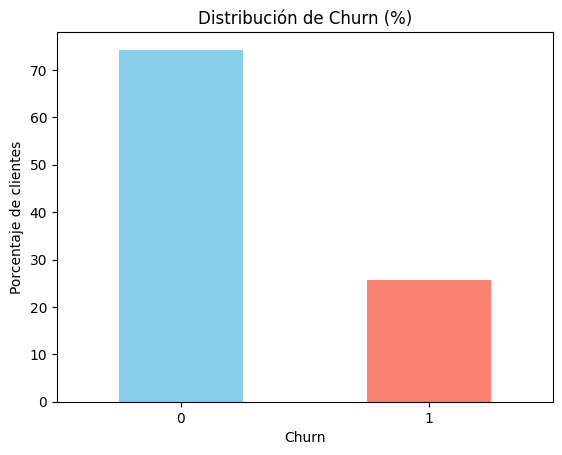

In [818]:
(df1['churn'].value_counts(normalize=True) * 100).plot(kind='bar', color=['skyblue','salmon'])

plt.title('Distribución de Churn (%)')
plt.xlabel('Churn')
plt.ylabel('Porcentaje de clientes')
plt.xticks(rotation=0)
plt.show()

In [819]:
categorical_cols = ['gender', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']

for col in categorical_cols:
    print(f"=== {col} ===")
    print(df1.groupby(col)['churn'].mean() * 100)
    print("\n")

=== gender ===
gender
female    26.141425
male      25.306122
Name: churn, dtype: float64


=== partner ===
partner
0    32.008536
1    19.016487
Name: churn, dtype: float64


=== dependents ===
dependents
0    30.338183
1    14.947272
Name: churn, dtype: float64


=== phoneservice ===
phoneservice
0    24.045262
1    25.899390
Name: churn, dtype: float64


=== multiplelines ===
multiplelines
0    24.250357
1    27.732463
Name: churn, dtype: float64


=== internetservice ===
internetservice
dsl            18.448553
fiber optic    40.556598
no              7.147375
Name: churn, dtype: float64


=== onlinesecurity ===
onlinesecurity
0    30.333398
1    14.196343
Name: churn, dtype: float64


=== onlinebackup ===
onlinebackup
0    28.259500
1    20.886581
Name: churn, dtype: float64


=== deviceprotection ===
deviceprotection
0    27.721943
1    21.878764
Name: churn, dtype: float64


=== techsupport ===
techsupport
0    30.195623
1    14.733840
Name: churn, dtype: float64


=== streaming

In [820]:
import matplotlib.pyplot as plt

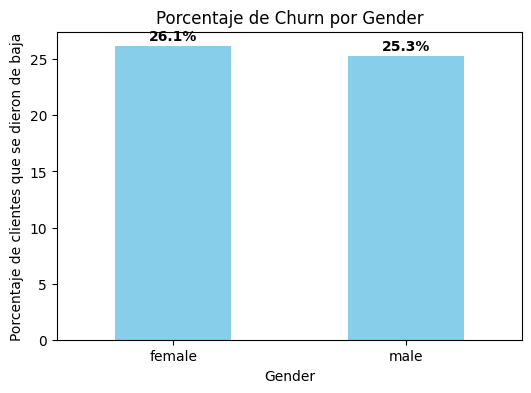

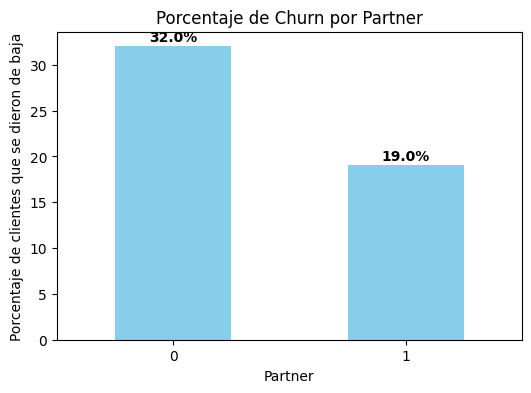

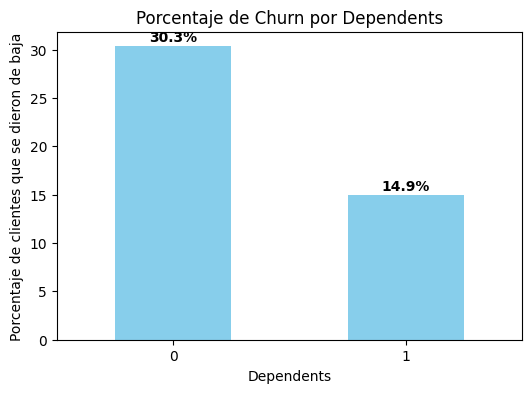

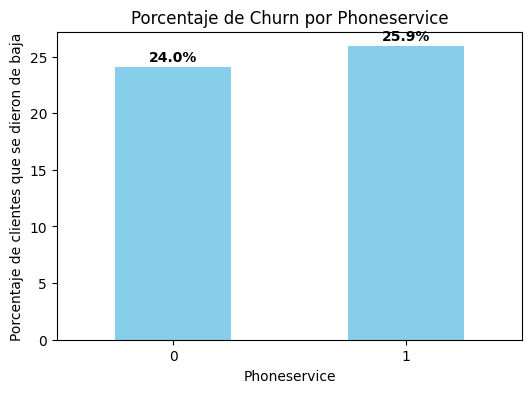

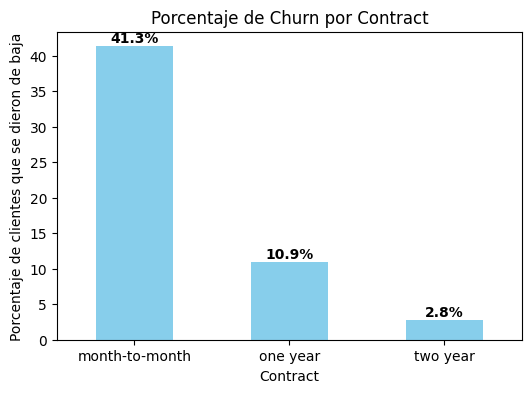

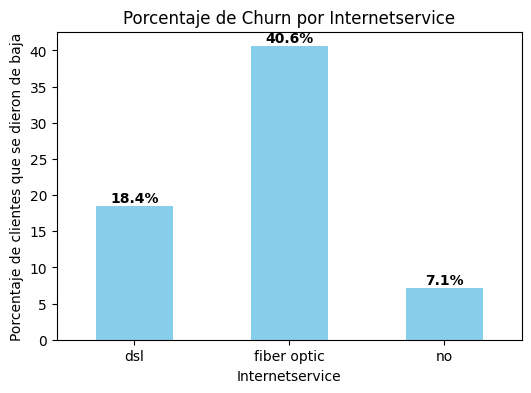

In [821]:
categorical_cols = ['gender','partner','dependents','phoneservice','contract','internetservice']

for col in categorical_cols:
    churn_por_col = df1.groupby(col)['churn'].mean() * 100
    plt.figure(figsize=(6,4))
    churn_por_col.plot(kind='bar', color='skyblue')

    plt.title(f'Porcentaje de Churn por {col.capitalize()}')
    plt.ylabel('Porcentaje de clientes que se dieron de baja')
    plt.xlabel(col.capitalize())
    plt.xticks(rotation=0)

    for i, v in enumerate(churn_por_col):
        plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

    plt.show()

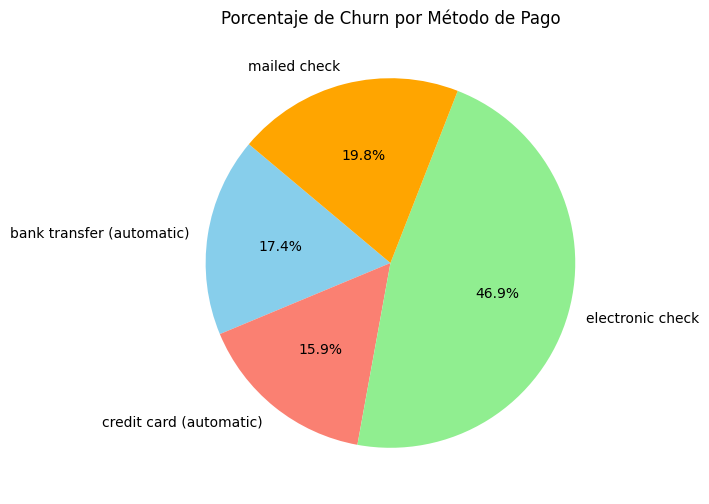

In [822]:
churn_payment = df1.groupby('paymentmethod')['churn'].mean() * 100

plt.figure(figsize=(6,6))
plt.pie(churn_payment, labels=churn_payment.index, autopct='%1.1f%%', startangle=140, colors=['skyblue','salmon','lightgreen','orange'])
plt.title('Porcentaje de Churn por Método de Pago')
plt.show()

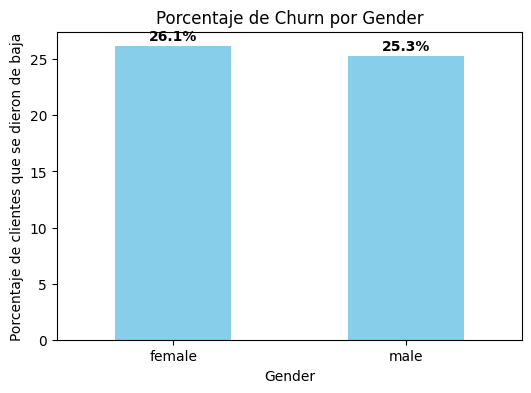

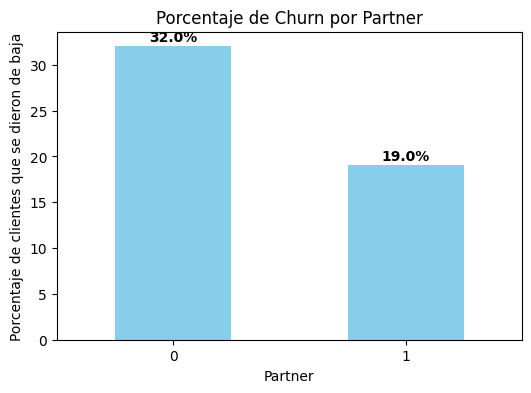

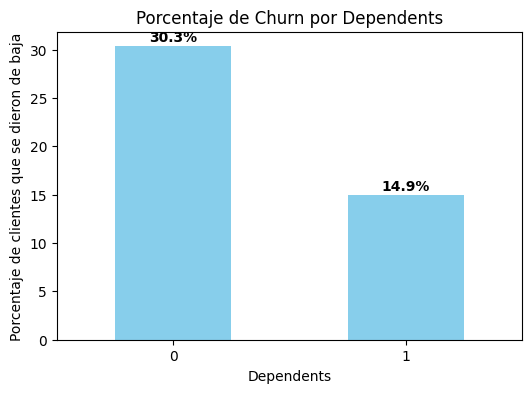

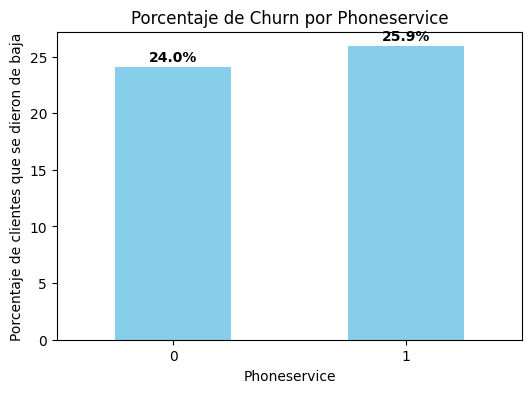

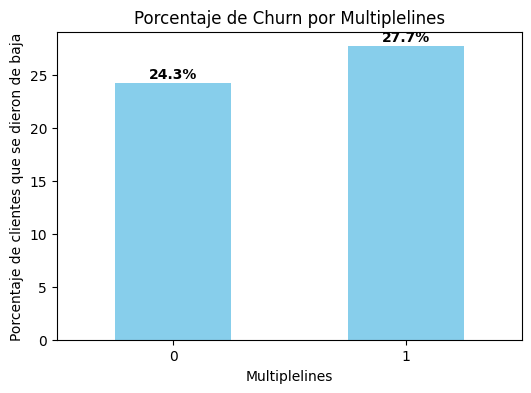

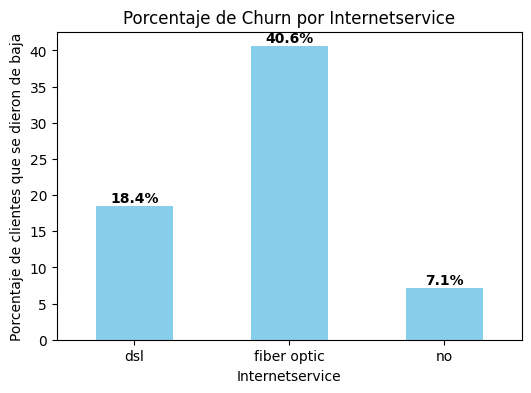

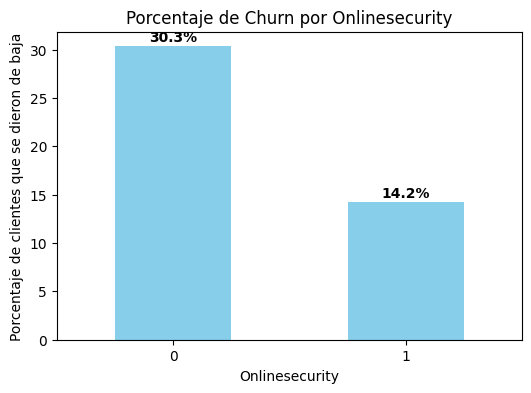

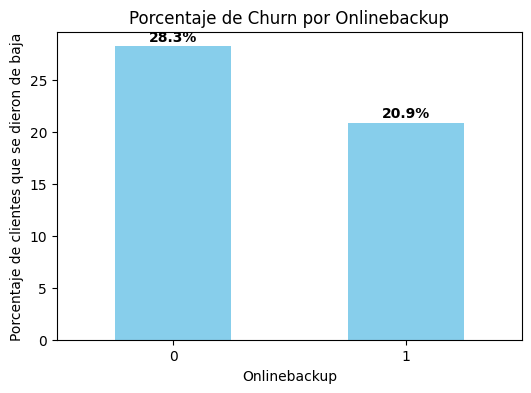

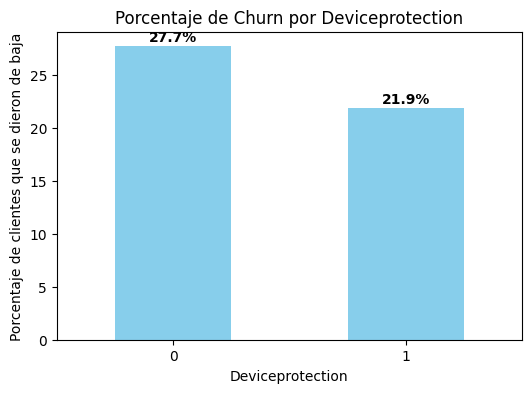

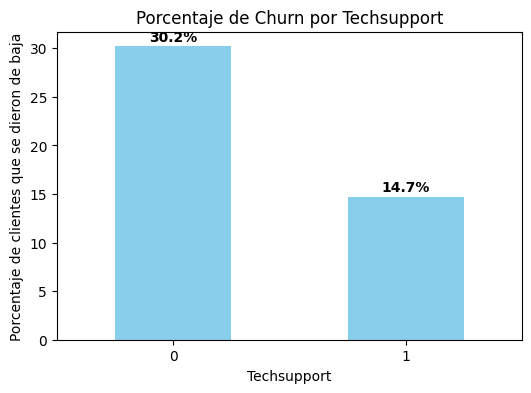

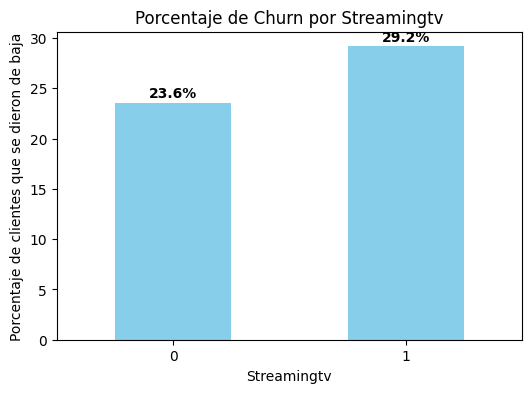

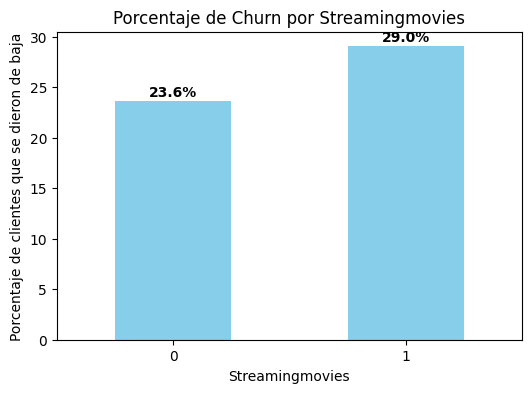

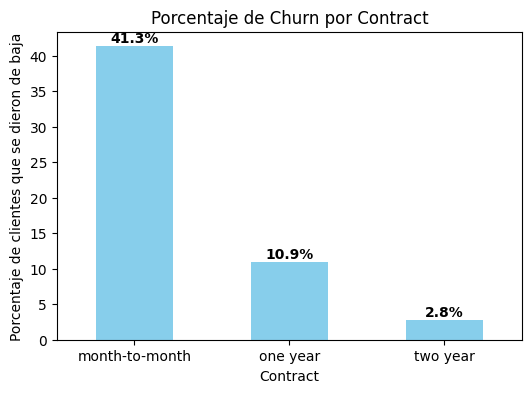

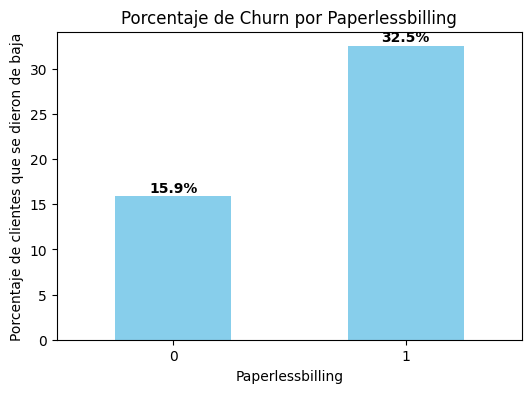

In [823]:
categorical_cols = ['gender', 'partner', 'dependents',
       'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity',
       'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv',
       'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod']

for col in categorical_cols:
    if col != 'paymentmethod':
        # % de churn por categoría
        churn_por_col = df1.groupby(col)['churn'].mean() * 100

        # Gráfico de barras
        plt.figure(figsize=(6,4))
        churn_por_col.plot(kind='bar', color='skyblue')
        plt.title(f'Porcentaje de Churn por {col.capitalize()}')
        plt.ylabel('Porcentaje de clientes que se dieron de baja')
        plt.xlabel(col.capitalize())
        plt.xticks(rotation=0)

        # Mostrar porcentaje encima de cada barra
        for i, v in enumerate(churn_por_col):
            plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

        plt.show()


# Informe de Análisis de Evasión de Clientes (Churn)
## - Introducción
El objetivo de este análisis es estudiar la **evasión de clientes (Churn)** en la empresa TelecomX, identificando los factores que influyen en la decisión de un cliente de cancelar su servicio o no.  
El análisis permitirá comprender patrones de comportamiento y ofrecer estrategias para reducir la evasión.
## - Limpieza y Tratamiento de Datos
Se realizaron los siguientes pasos:

1. Importación de datos desde un archivo .json a un DataFrame.
2. Normalizacion de los datos.
3. Identificación y tratamiento de valores faltantes (NaN):
   - Se hizo el tratamiento de datos de tiño string a float
   - Tratamiento de valores faltantes en otras columnas numéricas si existían.
4. Limpieza de texto:
   - Eliminación de espacios en blanco.
   - Conversión de texto a minúsculas.
5. Recodificación de variables:
   - `'yes'` → 1, `'no'` → 0 en columnas binarias.
   - `'no internet service'` → `'no'`.
6. Preparación de columnas categóricas para análisis y visualización.

##  Análisis Exploratorio de Datos
Se analizaron las siguientes variables categóricas en relación con `churn`:  
`gender`, `partner`, `dependents`, `phoneservice`, `multiplelines`, `internetservice`,  
`onlinesecurity`, `onlinebackup`, `deviceprotection`, `techsupport`, `streamingtv`,  
`streamingmovies`, `contract`, `paperlessbilling`, `paymentmethod`.

##  Conclusiones e Insights
- Los contratos **month-to-month** presentan la mayor evasión; contratos largos reducen churn.
- Clientes que utilizan **electronic check** muestran mayor probabilidad de cancelar.
- Tener **pareja o dependientes** reduce la probabilidad de churn.
- Servicios como **fibra óptica**, streaming de TV o películas aumentan la evasión.
- El Género y el servicio telefónico no muestra ninguna influencia significativa para la evasion

---

##  Recomendaciones
1. Incentivar los **contratos de mayor duración** para fidelizar a los clientes.
2. Fomentar el uso de **pagos automáticos** en lugar de cheques electrónicos, esto ayuda a fidelizar.
3. Ofrecer **beneficios o campañas especiales** a clientes sin pareja o dependientes con el finde evitar evasiones.
4. Mejorar la experiencia de los servicios con mayor churn (fibra óptica, streaming).
5. Implementar **estrategias personalizadas** según perfil de cliente para reducir la evasión.

#5. Correlaciones

In [824]:
numericas = df1.select_dtypes(include='number')
correlaciones = numericas.corr()
print(correlaciones)

                     churn  seniorcitizen   partner  dependents    tenure  \
churn             1.000000       0.146733 -0.148546   -0.161384 -0.344079   
seniorcitizen     0.146733       1.000000  0.022970   -0.212952  0.018187   
partner          -0.148546       0.022970  1.000000    0.448900  0.377551   
dependents       -0.161384      -0.212952  0.448900    1.000000  0.159892   
tenure           -0.344079       0.018187  0.377551    0.159892  1.000000   
phoneservice      0.012571       0.010060  0.018828   -0.003863  0.010205   
multiplelines     0.039343       0.144567  0.141187   -0.027894  0.331678   
onlinesecurity   -0.166828      -0.037953  0.141392    0.083951  0.327252   
onlinebackup     -0.080163       0.068824  0.139523    0.023686  0.361291   
deviceprotection -0.063452       0.060358  0.153209    0.014797  0.361792   
techsupport      -0.160440      -0.059376  0.116228    0.062586  0.322139   
streamingtv       0.062430       0.103655  0.124754   -0.015030  0.280738   